In [2]:
pip install ultralytics -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.9 MB/s eta 0:00:00


In [3]:
import requests

image_url = "https://ultralytics.com/images/bus.jpg"
image_path = "bus.jpg"

response = requests.get(image_url)
response.raise_for_status()  # Raise an exception for bad status codes

with open(image_path, 'wb') as f:
    f.write(response.content)

print(f"Downloaded image to {image_path}")

Downloaded image to bus.jpg


In [7]:
from ultralytics import YOLO
model = YOLO("yolov8n-seg.pt")
print("YOLOv8 segmentation model loaded successfully.")

YOLOv8 segmentation model loaded successfully.



image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 skateboard, 324.3ms
Speed: 11.0ms preprocess, 324.3ms inference, 18.3ms postprocess per image at shape (1, 3, 640, 480)
Segmentation completed. Displaying results:


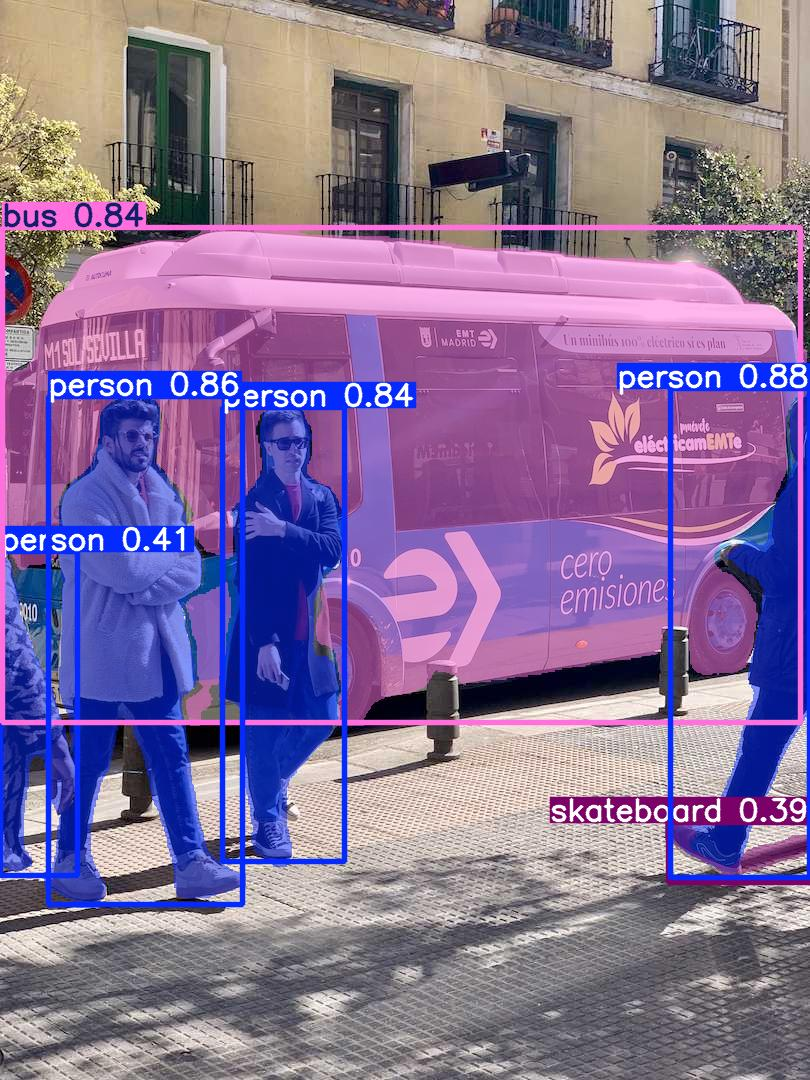

In [8]:
from IPython.display import Image as DisplayImage, display
from PIL import Image


results = model(image_path)

for r in results:
    im_array = r.plot()  # plot a BGR numpy array of predictions
    im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
    im.save('results.jpg') # save image

print("Segmentation completed. Displaying results:")
display(DisplayImage('results.jpg'))